## 1. Setup

In [1]:
# 0. Import
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2]:
# 1. Load
DATASET = "online_shoppers"
MESSY_DIR = f"../data/messy/{DATASET}"
CONDITIONS = ["clean", "missing_mild", "missing_severe",
              "outlier_mild", "outlier_severe", "noise_mild", "noise_severe"]

dfs = {}
for c in CONDITIONS:
    path = f"{MESSY_DIR}/{c}/train.csv"
    dfs[c] = pd.read_csv(path)
test_df = pd.read_csv(f"../data/processed/{DATASET}/test.csv")

for c, d in dfs.items():
    print(f"{c:<16} shape={d.shape}  missing={d.isnull().mean().mean():.2%}  pos_rate={d['Revenue'].mean():.3f}")
print(f"{'test':<16} shape={test_df.shape}")

clean            shape=(9864, 18)  missing=0.00%  pos_rate=0.155
missing_mild     shape=(9864, 18)  missing=7.77%  pos_rate=0.155
missing_severe   shape=(9864, 18)  missing=15.56%  pos_rate=0.155
outlier_mild     shape=(9864, 18)  missing=0.00%  pos_rate=0.155
outlier_severe   shape=(9864, 18)  missing=0.00%  pos_rate=0.155
noise_mild       shape=(9864, 18)  missing=0.00%  pos_rate=0.189
noise_severe     shape=(9864, 18)  missing=0.00%  pos_rate=0.293
test             shape=(2466, 18)


## 2. EDA

Following the protocol:
1. Basic data loading check (shape, info, columns, describe)
2. Basic descriptive stats (mean, median, std, skew)
3. Missing value profile (% and pattern)
4. Outlier profile (distribution shape, IQR count)
5. Class balance profile (check class balance)
6. Correlation matrix

In [3]:
# 1. Basic data loading (all conditions + test)
all_dfs = dfs.copy()
all_dfs["test"] = test_df

for name, d in all_dfs.items():
    print(f"\n{'='*70}\n  {name.upper()}\n{'='*70}")
    print(f"Data Shape: {d.shape}")
    print("\nData Info:")
    d.info()
    print("\nData Columns:")
    print(d.columns.tolist())
    print("\nData Description:")
    display(d.describe())


  CLEAN
Data Shape: (9864, 18)

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9864 entries, 0 to 9863
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           9864 non-null   int64  
 1   Administrative_Duration  9864 non-null   float64
 2   Informational            9864 non-null   int64  
 3   Informational_Duration   9864 non-null   float64
 4   ProductRelated           9864 non-null   int64  
 5   ProductRelated_Duration  9864 non-null   float64
 6   BounceRates              9864 non-null   float64
 7   ExitRates                9864 non-null   float64
 8   PageValues               9864 non-null   float64
 9   SpecialDay               9864 non-null   float64
 10  Month                    9864 non-null   object 
 11  OperatingSystems         9864 non-null   int64  
 12  Browser                  9864 non-null   int64  
 13  Region                   9864 non-

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType,Revenue
count,9864.000000,9864.000000,9864.000000,9864.000000,9864.000000,9864.000000,9864.000000,9864.000000,9864.000000,9864.000000,9864.000000,9864.000000,9864.000000,9864.000000,9864.000000
mean,2.317620,81.241059,0.504663,34.590252,31.452758,1186.546010,0.022396,0.043313,5.944562,0.062693,2.127534,2.366788,3.152778,4.071168,0.154704
std,3.319144,179.610421,1.275169,141.428972,43.615440,1909.252291,0.048809,0.048901,18.562169,0.201271,0.918098,1.732810,2.395939,4.015231,0.361641
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,7.000000,182.566071,0.000000,0.014286,0.000000,0.000000,2.000000,2.000000,1.000000,2.000000,0.000000
50%,1.000000,8.000000,0.000000,0.000000,18.000000,600.536667,0.003110,0.025195,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000,0.000000
75%,4.000000,93.000000,0.000000,0.000000,38.000000,1474.508333,0.017081,0.050000,0.000000,0.000000,3.000000,2.000000,4.000000,4.000000,0.000000
max,27.000000,3398.750000,24.000000,2549.375000,705.000000,63973.522230,0.200000,0.200000,361.763742,1.000000,8.000000,13.000000,9.000000,20.000000,1.000000



  MISSING_MILD
Data Shape: (9864, 18)

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9864 entries, 0 to 9863
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           8878 non-null   float64
 1   Administrative_Duration  8878 non-null   float64
 2   Informational            8878 non-null   float64
 3   Informational_Duration   8878 non-null   float64
 4   ProductRelated           8878 non-null   float64
 5   ProductRelated_Duration  8878 non-null   float64
 6   BounceRates              8878 non-null   float64
 7   ExitRates                8878 non-null   float64
 8   PageValues               8878 non-null   float64
 9   SpecialDay               8878 non-null   float64
 10  Month                    9864 non-null   object 
 11  OperatingSystems         8878 non-null   float64
 12  Browser                  8878 non-null   float64
 13  Region                   88

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType,Revenue
count,8878.000000,8878.000000,8878.000000,8878.000000,8878.000000,8878.000000,8878.000000,8878.000000,8878.000000,8878.000000,8878.000000,8878.000000,8878.000000,8878.000000,9864.000000
mean,2.320680,80.804945,0.509800,34.001506,31.501690,1182.679619,0.022468,0.043398,5.884815,0.062064,2.128633,2.357851,3.151836,4.051588,0.154704
std,3.330201,175.656653,1.287046,137.447304,43.806809,1821.974060,0.048891,0.048984,18.358827,0.200125,0.908393,1.703164,2.394874,3.988583,0.361641
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,7.000000,182.312500,0.000000,0.014286,0.000000,0.000000,2.000000,2.000000,1.000000,2.000000,0.000000
50%,1.000000,7.500000,0.000000,0.000000,18.000000,598.680556,0.003107,0.025190,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000,0.000000
75%,4.000000,94.000000,0.000000,0.000000,38.000000,1477.904068,0.017126,0.050000,0.000000,0.000000,3.000000,2.000000,4.000000,4.000000,0.000000
max,27.000000,2720.500000,24.000000,2256.916667,705.000000,43171.233380,0.200000,0.200000,361.763742,1.000000,8.000000,13.000000,9.000000,20.000000,1.000000



  MISSING_SEVERE
Data Shape: (9864, 18)

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9864 entries, 0 to 9863
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           7891 non-null   float64
 1   Administrative_Duration  7891 non-null   float64
 2   Informational            7891 non-null   float64
 3   Informational_Duration   7891 non-null   float64
 4   ProductRelated           7891 non-null   float64
 5   ProductRelated_Duration  7891 non-null   float64
 6   BounceRates              7891 non-null   float64
 7   ExitRates                7891 non-null   float64
 8   PageValues               7891 non-null   float64
 9   SpecialDay               7891 non-null   float64
 10  Month                    9864 non-null   object 
 11  OperatingSystems         7891 non-null   float64
 12  Browser                  7891 non-null   float64
 13  Region                   

...

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType,Revenue
count,9864.000000,9864.000000,9864.000000,9864.000000,9864.000000,9864.000000,9864.000000,9864.000000,9864.000000,9864.000000,9864.000000,9864.000000,9864.000000,9864.000000,9864.000000
mean,2.317620,81.241059,0.504663,34.590252,31.452758,1186.546010,0.022396,0.043313,5.944562,0.062693,2.127534,2.366788,3.152778,4.071168,0.188666
std,3.319144,179.610421,1.275169,141.428972,43.615440,1909.252291,0.048809,0.048901,18.562169,0.201271,0.918098,1.732810,2.395939,4.015231,0.391263
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,7.000000,182.566071,0.000000,0.014286,0.000000,0.000000,2.000000,2.000000,1.000000,2.000000,0.000000
50%,1.000000,8.000000,0.000000,0.000000,18.000000,600.536667,0.003110,0.025195,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000,0.000000
75%,4.000000,93.000000,0.000000,0.000000,38.000000,1474.508333,0.017081,0.050000,0.000000,0.000000,3.000000,2.000000,4.000000,4.000000,0.000000
max,27.000000,3398.750000,24.000000,2549.375000,705.000000,63973.522230,0.200000,0.200000,361.763742,1.000000,8.000000,13.000000,9.000000,20.000000,1.000000



  NOISE_SEVERE
Data Shape: (9864, 18)

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9864 entries, 0 to 9863
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           9864 non-null   int64  
 1   Administrative_Duration  9864 non-null   float64
 2   Informational            9864 non-null   int64  
 3   Informational_Duration   9864 non-null   float64
 4   ProductRelated           9864 non-null   int64  
 5   ProductRelated_Duration  9864 non-null   float64
 6   BounceRates              9864 non-null   float64
 7   ExitRates                9864 non-null   float64
 8   PageValues               9864 non-null   float64
 9   SpecialDay               9864 non-null   float64
 10  Month                    9864 non-null   object 
 11  OperatingSystems         9864 non-null   int64  
 12  Browser                  9864 non-null   int64  
 13  Region                   98

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType,Revenue
count,9864.000000,9864.000000,9864.000000,9864.000000,9864.000000,9864.000000,9864.000000,9864.000000,9864.000000,9864.000000,9864.000000,9864.000000,9864.000000,9864.000000,9864.000000
mean,2.317620,81.241059,0.504663,34.590252,31.452758,1186.546010,0.022396,0.043313,5.944562,0.062693,2.127534,2.366788,3.152778,4.071168,0.293289
std,3.319144,179.610421,1.275169,141.428972,43.615440,1909.252291,0.048809,0.048901,18.562169,0.201271,0.918098,1.732810,2.395939,4.015231,0.455293
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,7.000000,182.566071,0.000000,0.014286,0.000000,0.000000,2.000000,2.000000,1.000000,2.000000,0.000000
50%,1.000000,8.000000,0.000000,0.000000,18.000000,600.536667,0.003110,0.025195,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000,0.000000
75%,4.000000,93.000000,0.000000,0.000000,38.000000,1474.508333,0.017081,0.050000,0.000000,0.000000,3.000000,2.000000,4.000000,4.000000,1.000000
max,27.000000,3398.750000,24.000000,2549.375000,705.000000,63973.522230,0.200000,0.200000,361.763742,1.000000,8.000000,13.000000,9.000000,20.000000,1.000000



  TEST
Data Shape: (2466, 18)

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2466 entries, 0 to 2465
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           2466 non-null   int64  
 1   Administrative_Duration  2466 non-null   float64
 2   Informational            2466 non-null   int64  
 3   Informational_Duration   2466 non-null   float64
 4   ProductRelated           2466 non-null   int64  
 5   ProductRelated_Duration  2466 non-null   float64
 6   BounceRates              2466 non-null   float64
 7   ExitRates                2466 non-null   float64
 8   PageValues               2466 non-null   float64
 9   SpecialDay               2466 non-null   float64
 10  Month                    2466 non-null   object 
 11  OperatingSystems         2466 non-null   int64  
 12  Browser                  2466 non-null   int64  
 13  Region                   2466 non-n

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType,Revenue
count,2466.000000,2466.000000,2466.000000,2466.000000,2466.000000,2466.000000,2466.000000,2466.000000,2466.000000,2466.000000,2466.000000,2466.000000,2466.000000,2466.000000,2466.000000
mean,2.305353,79.128815,0.499189,34.000983,32.846310,1227.547061,0.021375,0.042111,5.668042,0.056367,2.109895,2.318329,3.125710,4.063260,0.154907
std,3.332979,164.992517,1.250152,138.024375,47.754225,1931.277884,0.047185,0.047355,18.595609,0.189164,0.883754,1.653457,2.424439,4.065495,0.361889
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,7.000000,190.627083,0.000000,0.014286,0.000000,0.000000,2.000000,2.000000,1.000000,2.000000,0.000000
50%,1.000000,6.500000,0.000000,0.000000,19.000000,590.568333,0.003125,0.025000,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000,0.000000
75%,3.000000,93.975000,0.000000,0.000000,38.000000,1436.318029,0.016429,0.050000,0.000000,0.000000,3.000000,2.000000,4.000000,4.000000,0.000000
max,26.000000,2407.423810,14.000000,1778.000000,518.000000,27009.859430,0.200000,0.200000,360.953384,1.000000,8.000000,13.000000,9.000000,20.000000,1.000000


In [4]:
# 2. Basic descriptive stats (mean, median, std, skew)

# number columns only
num_cols = []
for col in all_dfs["clean"].select_dtypes(include="number").columns:
    if col != "Revenue" and col != "ID":
        num_cols.append(col)

d = all_dfs["clean"][num_cols]
stats = pd.DataFrame({
    "mean": d.mean(), "median": d.median(), "std": d.std(), "skew": d.skew()
}).round(3)

print(stats.to_string())

                             mean   median       std   skew
Administrative              2.318    1.000     3.319  1.967
Administrative_Duration    81.241    8.000   179.610  5.679
Informational               0.505    0.000     1.275  4.142
Informational_Duration     34.590    0.000   141.429  7.702
ProductRelated             31.453   18.000    43.615  4.372
ProductRelated_Duration  1186.546  600.537  1909.252  8.009
BounceRates                 0.022    0.003     0.049  2.924
ExitRates                   0.043    0.025     0.049  2.130
PageValues                  5.945    0.000    18.562  6.187
SpecialDay                  0.063    0.000     0.201  3.261
OperatingSystems            2.128    2.000     0.918  2.103
Browser                     2.367    2.000     1.733  3.236
Region                      3.153    3.000     2.396  0.984
TrafficType                 4.071    2.000     4.015  1.965


In [5]:
# 3. Missing value profile (% per column, all conditions)
missing_pct = pd.DataFrame(
    {name: d.isnull().mean() * 100 for name, d in all_dfs.items()}
).round(2)

print("Missing Value in % (per column, per condition):")
print(missing_pct.to_string())

print("\nOverall missing % per condition:")
print(missing_pct.mean().round(2).to_string())

Missing Value in % (per column, per condition):
                         clean  missing_mild  missing_severe  outlier_mild  outlier_severe  noise_mild  noise_severe  test
Administrative             0.0          10.0            20.0           0.0             0.0         0.0           0.0   0.0
Administrative_Duration    0.0          10.0            20.0           0.0             0.0         0.0           0.0   0.0
Informational              0.0          10.0            20.0           0.0             0.0         0.0           0.0   0.0
Informational_Duration     0.0          10.0            20.0           0.0             0.0         0.0           0.0   0.0
ProductRelated             0.0          10.0            20.0           0.0             0.0         0.0           0.0   0.0
ProductRelated_Duration    0.0          10.0            20.0           0.0             0.0         0.0           0.0   0.0
BounceRates                0.0          10.0            20.0           0.0             0.0 

In [6]:
# 3b. Missing pattern
for name in ["missing_mild", "missing_severe"]:
    d = all_dfs[name]
    print(f"\n{name.upper()} - missing % by target class:")
    table = d.groupby("Revenue").apply(lambda g: g[num_cols].isnull().mean()*100)
    print(table.round(2).T.to_string())


MISSING_MILD - missing % by target class:
Revenue                     0      1
Administrative           9.86  10.75
Administrative_Duration  9.86  10.75
Informational            9.86  10.75
Informational_Duration   9.86  10.75
ProductRelated           9.86  10.75
ProductRelated_Duration  9.86  10.75
BounceRates              9.86  10.75
ExitRates                9.86  10.75
PageValues               9.86  10.75
SpecialDay               9.86  10.75
OperatingSystems         9.86  10.75
Browser                  9.86  10.75
Region                   9.86  10.75
TrafficType              9.86  10.75

MISSING_SEVERE - missing % by target class:
Revenue                      0      1
Administrative           19.78  21.23
Administrative_Duration  19.78  21.23
Informational            19.78  21.23
Informational_Duration   19.78  21.23
ProductRelated           19.78  21.23
ProductRelated_Duration  19.78  21.23
BounceRates              19.78  21.23
ExitRates                19.78  21.23
PageValues     

C:\Users\ARYA\AppData\Local\Temp\ipykernel_900\1384887210.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  table = d.groupby("Revenue").apply(lambda g: g[num_cols].isnull().mean()*100)
C:\Users\ARYA\AppData\Local\Temp\ipykernel_900\1384887210.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  table = d.groupby("Revenue").apply(lambda g: g[num_cols].isnull().mean()*100)


In [7]:
# 4. Outlier profile (distribution shape, IQR count)
def iqr_outlier_pct(d, cols):
    out = {}
    for c in cols:
        q1, q3 = d[c].quantile([0.25, 0.75])
        iqr = q3 - q1
        lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        out[c] = ((d[c] < lo) | (d[c] > hi)).mean() * 100
    return pd.Series(out)

outlier_pct = pd.DataFrame(
    {name: iqr_outlier_pct(d, num_cols) for name, d in all_dfs.items()}
).round(2)

print("IQR outlier % (per column, per condition):")
print(outlier_pct.to_string())

skew = pd.DataFrame(
    {name: d[num_cols].skew() for name, d in all_dfs.items()}
).round(2)

print("\nSkewness (per column, per condition):")
print(skew.to_string())

IQR outlier % (per column, per condition):
                         clean  missing_mild  missing_severe  outlier_mild  outlier_severe  noise_mild  noise_severe   test
Administrative            3.35          3.05            2.63          8.14           17.88        3.35          3.35   9.33
Administrative_Duration   9.46          8.36            7.68         13.27           20.70        9.46          9.46   9.61
Informational            21.46         19.53           17.48         11.46           16.12       21.46         21.46  20.84
Informational_Duration   19.53         17.73           15.90         23.50           31.72       19.53         19.53  19.42
ProductRelated            7.96          7.19            6.44         12.03           19.80        7.96          7.96   8.19
ProductRelated_Duration   7.56          6.73            5.99         11.57           19.50        7.56          7.56   8.64
BounceRates              12.63         11.44           10.12         16.56           24.0

In [8]:
# Ground-truth injection rate + range check
for cond in ["outlier_mild", "outlier_severe"]:
    d = all_dfs[cond]
    changed = (d[num_cols] != all_dfs["clean"][num_cols]).mean() * 100
    summary = pd.DataFrame({
        "changed_%": changed.round(2),
        "clean_min": all_dfs["clean"][num_cols].min(),
        "clean_max": all_dfs["clean"][num_cols].max(),
        f"{cond}_min": d[num_cols].min(),
        f"{cond}_max": d[num_cols].max(),
        "clean_std": all_dfs["clean"][num_cols].std().round(2),
        f"{cond}_std": d[num_cols].std().round(2),
    })
    print(f"\n{cond.upper()}")
    print(summary.to_string())


OUTLIER_MILD
                         changed_%  clean_min     clean_max  outlier_mild_min  outlier_mild_max  clean_std  outlier_mild_std
Administrative                4.99        0.0     27.000000        -10.000000         27.000000       3.32              4.06
Administrative_Duration       5.00        0.0   3398.750000       -636.506388       3398.750000     179.61            223.94
Informational                 5.00        0.0     24.000000          0.000000         25.000000       1.28              5.48
Informational_Duration        5.00        0.0   2549.375000       -531.035249       2549.375000     141.43            175.60
ProductRelated                5.00        0.0    705.000000       -143.000000        705.000000      43.62             54.32
ProductRelated_Duration       5.00        0.0  63973.522230      -6444.637395      63973.522230    1909.25           2366.97
BounceRates                   5.00        0.0      0.200000         -0.172801          0.216704       0.05     

In [9]:
# 5. Class balance profile (check class balance)
balance = pd.DataFrame(
    {name: d["Revenue"].value_counts(normalize=True).sort_index() * 100 for name, d in all_dfs.items()}
).round(2)

print("Class balance % (y=0 / y=1):")
print(balance.to_string())

Class balance % (y=0 / y=1):
         clean  missing_mild  missing_severe  outlier_mild  outlier_severe  noise_mild  noise_severe   test
Revenue                                                                                                    
0        84.53         84.53           84.53         84.53           84.53       81.13         70.67  84.51
1        15.47         15.47           15.47         15.47           15.47       18.87         29.33  15.49


In [10]:
# 5b. Direct label noise check (ground truth vs clean)
clean_y = all_dfs["clean"]["Revenue"]

for cond in ["noise_mild", "noise_severe"]:
    noisy_y = all_dfs[cond]["Revenue"]
    flipped = noisy_y != clean_y
    print(f"\n{cond.upper()}")
    print(f"  Overall flip rate : {flipped.mean():.2%}")
    print(f"  Flipped 0 → 1     : {((clean_y == 0) & flipped).sum():,} "
          f"({flipped[clean_y == 0].mean():.2%} of class 0)")
    print(f"  Flipped 1 → 0     : {((clean_y == 1) & flipped).sum():,} "
          f"({flipped[clean_y == 1].mean():.2%} of class 1)")


NOISE_MILD
  Overall flip rate : 5.00%
  Flipped 0 → 1     : 414 (4.97% of class 0)
  Flipped 1 → 0     : 79 (5.18% of class 1)

NOISE_SEVERE
  Overall flip rate : 20.00%
  Flipped 0 → 1     : 1,670 (20.03% of class 0)
  Flipped 1 → 0     : 303 (19.86% of class 1)


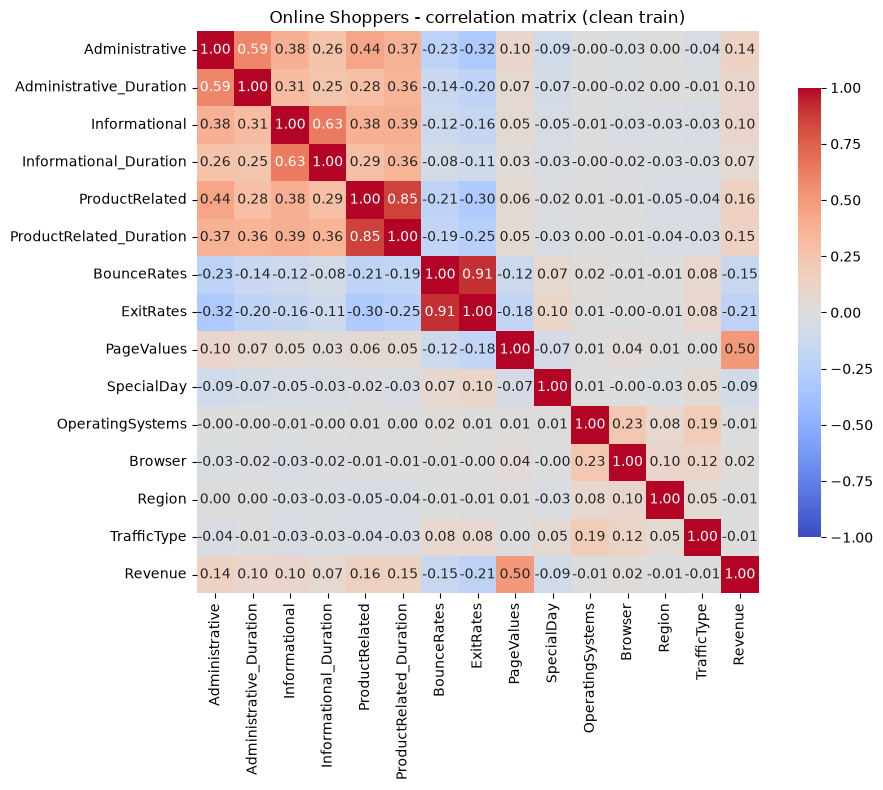

Correlation with y (per condition):
                         clean  missing_mild  missing_severe  outlier_mild  outlier_severe  noise_mild  noise_severe   test
Administrative           0.143         0.138           0.158         0.107           0.072       0.107         0.061  0.124
Administrative_Duration  0.099         0.098           0.107         0.080           0.064       0.073         0.046  0.069
Informational            0.097         0.099           0.104         0.024           0.009       0.073         0.038  0.086
Informational_Duration   0.069         0.076           0.074         0.056           0.047       0.052         0.021  0.077
ProductRelated           0.156         0.160           0.160         0.127           0.086       0.125         0.071  0.170
ProductRelated_Duration  0.146         0.159           0.148         0.111           0.074       0.120         0.074  0.178
BounceRates             -0.154        -0.154          -0.152        -0.117          -0.082      

In [12]:
# 6. Correlation matrix
corr_cols = num_cols + ["Revenue"]

# 6a. Full heatmap - clean baseline
corr_clean = all_dfs["clean"][corr_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_clean, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            vmin=-1, vmax=1, square=True, cbar_kws={"shrink": 0.8})
plt.title("Online Shoppers - correlation matrix (clean train)")
plt.tight_layout()
plt.show()

# 6b. Correlation with target, per condition
target_corr = pd.DataFrame(
    {name: d[corr_cols].corr()["Revenue"].drop("Revenue") for name, d in all_dfs.items()}
).round(3)

print("Correlation with y (per condition):")
print(target_corr.to_string())

# 6c. How much each condition distorts the whole matrix vs clean
distortion = pd.Series(
    {name: (d[corr_cols].corr() - corr_clean).abs().values.mean() for name, d in all_dfs.items()}
).round(4)

print("\nMean absolute change in correlation vs clean:")
print(distortion.to_string())